<a href="https://colab.research.google.com/github/Jhoniisjelly/Data201_JhonathanUrquilla/blob/main/Data_201_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data 201 Final Project
## CNR: 31975
## Spring 2026
### Jhonathan Urquilla

# **Introduction**

### The data set I will be using is titled **Real Property Tax - 2024** and it contains data from Montgomery County, Maryland. The data is about property tax bills for properties in the county. It includes information such as residence type, property city, state, zip code, tax class, assessment value, total credits, and bill total.

### This data set is useful because it connects directly to Montgomery County and property taxes are important for residents, homeowners, and local government budgets. Being able to predict the total bill can help show which property characteristics are most related to higher or lower property tax bills.

### The data set is from 2024, so it may not represent future property taxes exactly. The data may also have errors from missing values, or old records. Another limitation is that the model can show patterns, but it does not prove that one variable causes a higher tax bill.

### **Prediction goal:** I want to predict the **Bill Total** for a property using variables from the data set such as residence type, city, zip code, tax class, assessment value, and total credits.

### **Citation:** Montgomery County Open Data. *Real Property Tax - 2024*. Montgomery County, Maryland Open Data Portal. data.montgomerycountymd.gov/Finance-Tax-Property/Real-Property-Tax-2024/vpss-wfub/about_data."

# **Dataset and Preparation**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df =  pd.read_csv ("https://media.githubusercontent.com/media/Jhoniisjelly/Data201_JhonathanUrquilla/refs/heads/main/Final%20Project/Dataset/Real_Property_Tax_2024.csv")

df.head()

/tmp/ipykernel_4586/128869942.py:11: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv ("https://media.githubusercontent.com/media/Jhoniisjelly/Data201_JhonathanUrquilla/refs/heads/main/Final%20Project/Dataset/Real_Property_Tax_2024.csv")


,PARCEL CODE,RESIDENCE,PROPERTY ADDRESS,CITY,STATE,ZIP CODE,TAX CLASS,ASSESSMENT,BARNESVILLE PROPERTY TAX,BATTERY PARK PROPERTY TAX,...,MUNICIPAL HOMEOWNERS' CREDIT,MUNICIPAL HOMESTEAD CREDIT,MUNICIPAL SWIMCLUB,OTHER PARTIAL EXEMPTION,PUBLIC SAFETY OFFICERS TAX CR,STATE HOMEOWNER'S CREDIT,STATE HOMESTEAD CREDIT,SWIMCLUB,TOTAL CREDITS,BILL TOTAL
0,51203,NOT A PRINCIPAL RESIDENCE,VEIRS MILL RD,NaN,MD,NaN,R038,$0,$0,$0,...,$0,$0,$0,$0,$0,$0,$0,$0,$0,$0
1,3802634,NOT A PRINCIPAL RESIDENCE,8302 WOODMONT AVE P3 M,NaN,MD,NaN,R038,"$5,000",$0,$0,...,$0,$0,$0,$0,$0,$0,$0,$0,$0,$64.78
2,1571023,NOT A PRINCIPAL RESIDENCE,PUMPKIN SEED CT,NaN,MD,NaN,R042,$0,$0,$0,...,$0,$0,$0,$0,$0,$0,$0,$0,$0,$787.82
3,3728254,NOT A PRINCIPAL RESIDENCE,NORBECK RD,NaN,MD,NaN,R042,$0,$0,$0,...,$0,$0,$0,$0,$0,$0,$0,$0,$0,$0
4,3870056,NOT A PRINCIPAL RESIDENCE,DINGWELL WAY,NaN,MD,NaN,R053,"$524,100",$0,$0,...,$0,$0,$0,$0,$0,$0,$0,$0,$0,"$6,442.94"


| Column | Description | Type |
|---|---|---|
| RESIDENCE | Whether the property is a principal residence or not | Categorical |
| CITY | City where the property is located | Categorical |
| STATE | State where the property is located | Categorical |
| ZIP CODE | ZIP code for the property | Categorical/Numeric |
| TAX CLASS | Tax class assigned to the property | Categorical |
| ASSESSMENT | Assessed value of the property | Quantitative |
| TOTAL CREDITS | Total tax credits applied to the property | Quantitative |
| BILL TOTAL | Final tax bill amount, which is the target variable | Quantitative target |

In [41]:
shape = df.shape
print(shape)

(345409, 75)


In [42]:
df = df[[
    "RESIDENCE",
    "ASSESSMENT",
    "TOTAL CREDITS",
    "TAX CLASS",
    "CITY",
    "BILL TOTAL"
]]

df.head()

,RESIDENCE,ASSESSMENT,TOTAL CREDITS,TAX CLASS,CITY,BILL TOTAL
0,NOT A PRINCIPAL RESIDENCE,$0,$0,R038,NaN,$0
1,NOT A PRINCIPAL RESIDENCE,"$5,000",$0,R038,NaN,$64.78
2,NOT A PRINCIPAL RESIDENCE,$0,$0,R042,NaN,$787.82
3,NOT A PRINCIPAL RESIDENCE,$0,$0,R042,NaN,$0
4,NOT A PRINCIPAL RESIDENCE,"$524,100",$0,R053,NaN,"$6,442.94"


In [43]:
def clean_tax(col):
    return pd.to_numeric(col.astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False))


df["ASSESSMENT"] = clean_tax(df["ASSESSMENT"])
df["BILL TOTAL"] = clean_tax(df["BILL TOTAL"])
df["TOTAL CREDITS"] = clean_tax(df["TOTAL CREDITS"])

# Remove missing values
df = df.dropna()

# Only visualizing bills under 100,000 as there are extreme outliers
df = df[df["BILL TOTAL"] < 100000]

df = df.sample(n=50000, random_state=42)

# Display NA values if any left
print(df.isna().sum())

RESIDENCE        0
ASSESSMENT       0
TOTAL CREDITS    0
TAX CLASS        0
CITY             0
BILL TOTAL       0
dtype: int64


In [44]:
shape = df.shape
print(shape)

(50000, 6)


### The new size of the datset becomes 50,000 rows with 6 columns. I stuck with this number as the data was too large and preventing me from continuing to finish the project

In [45]:
categorical_cols = ["RESIDENCE", "TAX CLASS", "CITY"]
numerical_cols = ["ASSESSMENT", "TOTAL CREDITS"]

X = df[categorical_cols + numerical_cols]
y = df["BILL TOTAL"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)



print(X_encoded.shape)
print(len(y))

(50000, 138)
50000


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 138)
(10000, 138)


# **Exploratory Data Analysis**

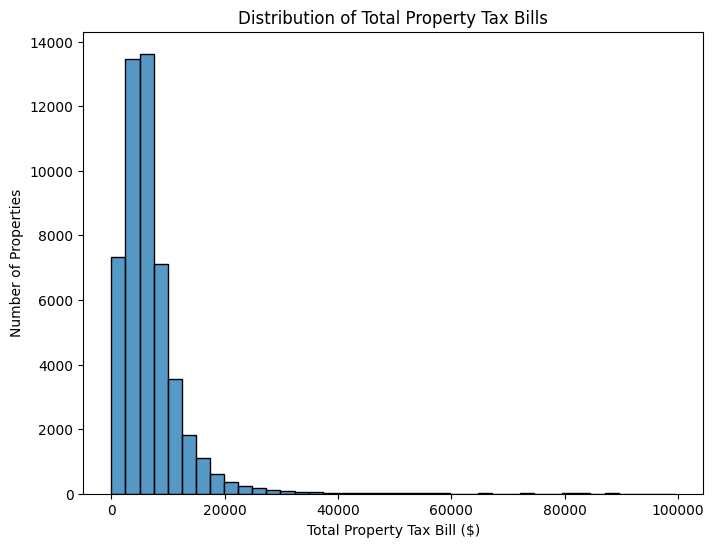

In [47]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["BILL TOTAL"], bins = 40)

plt.xlabel("Total Property Tax Bill ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Total Property Tax Bills")

plt.show()

### The histogram shows the distribution of the total property tax bills for most properties in Montgomery County. The distribution is right-skewed, meaning that most properties have lower tax bills while fewer properties have extremely large tax bills. Extreme outliers above 100,000 dollars were removed from the visualization to make the distribution easier to observe and interpert.

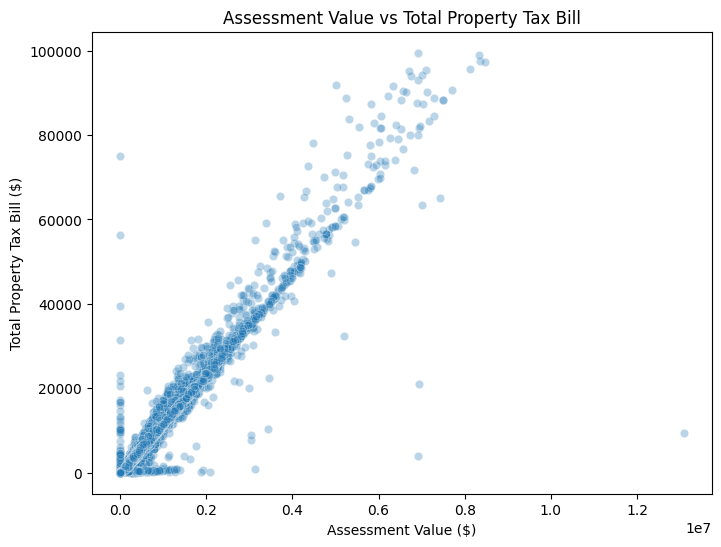

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["ASSESSMENT"],
    y=df["BILL TOTAL"],
    alpha=0.3
)

plt.xlabel("Assessment Value ($)")
plt.ylabel("Total Property Tax Bill ($)")
plt.title("Assessment Value vs Total Property Tax Bill")

plt.show()

### This scatterplot shows the relationship between property assessment values and total property tax bills in Montgomery County. The graph does show a strong positive relationship where properties with higher assessment values generally have higher tax bills. Most properties are clustered at lower assessment values while a smaller number of properties have extremely high assessments and tax bills. This suggests that assessment value will likely be one of the most important predictors.

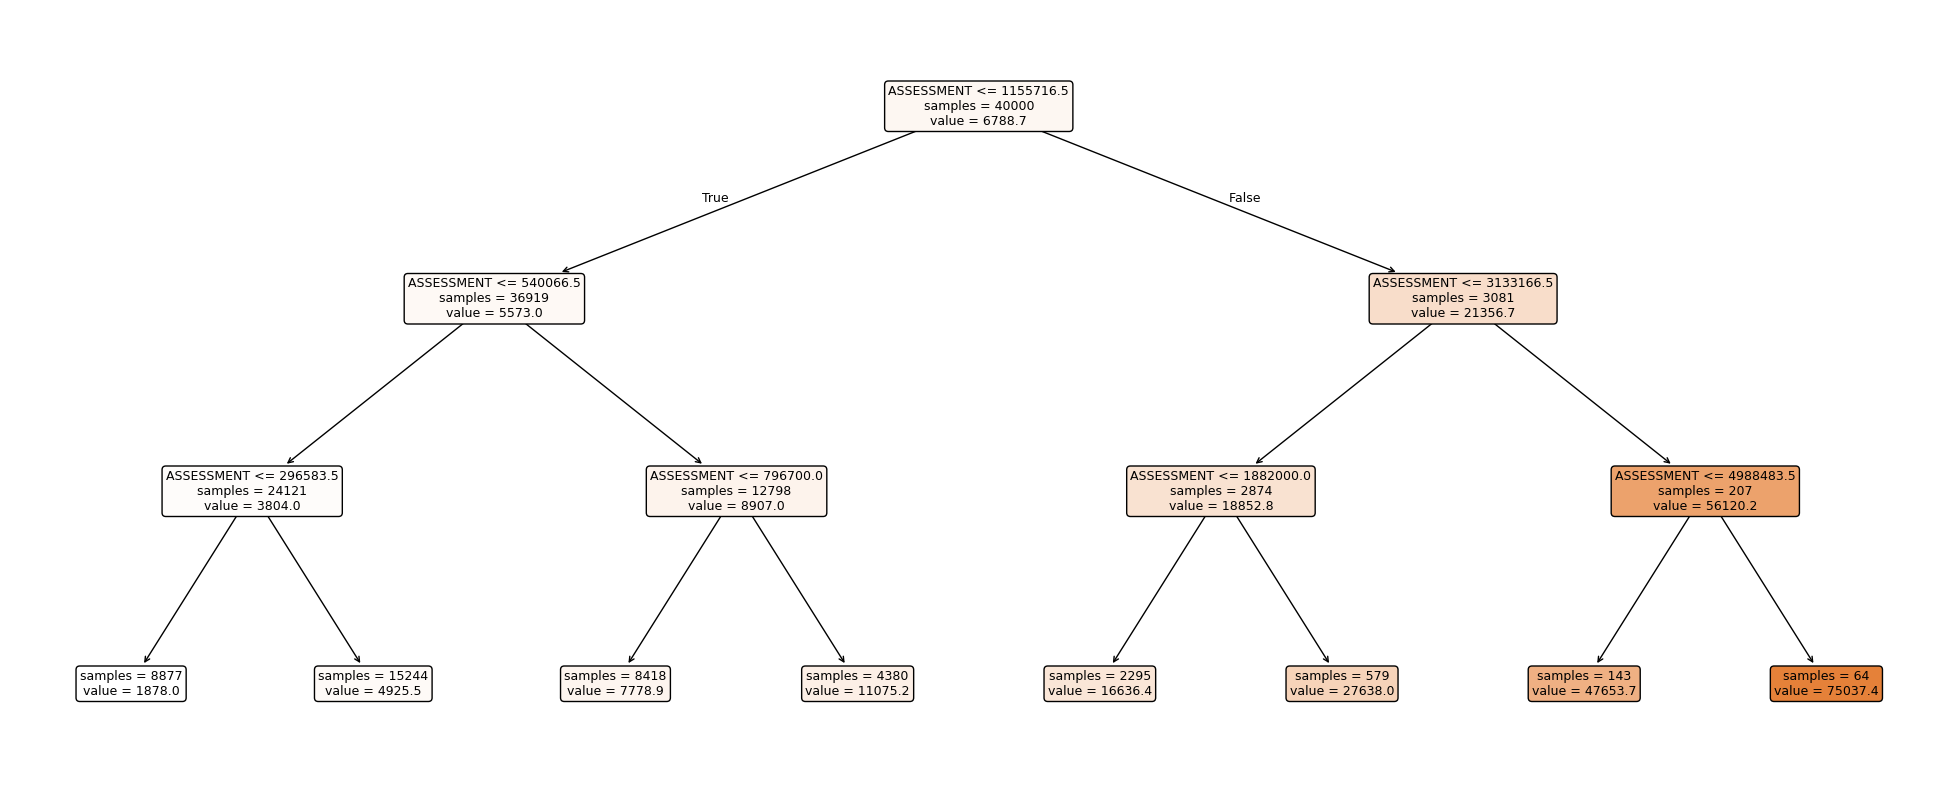

In [49]:
tree_small = DecisionTreeRegressor(max_depth=3, random_state=42)

tree_small.fit(X_train, y_train)

plt.figure(figsize=(25,10))

plot_tree(
    tree_small, filled=True, feature_names=list(X_train.columns), max_depth=3, rounded=True, fontsize=9, precision=1, impurity=False)

plt.show()

### The root node of the decision tree is assessment value which makes sense because property taxes are strongly connected to property assessments. Properties with higher assessments generally have larger property tax bills.

### One important split in the tree separates properties with lower assessment values from properties with higher assessment values. The model then continues splitting based on other variables such as total credits and property class.

### One example prediction path would be if a property had an assessment value below a certain amount but also had low tax credits, the model would predict a lower property tax bill.

In [50]:
tree_big = DecisionTreeRegressor(max_depth=6, random_state=42)

tree_big.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

In [51]:
tree_small_train_r2 = tree_small.score(X_train, y_train)
tree_small_test_r2 = tree_small.score(X_test, y_test)
tree_big_train_r2 = tree_big.score(X_train, y_train)
tree_big_test_r2 = tree_big.score(X_test, y_test)

print(f"Small Tree Train R^2: {tree_small_train_r2:.4f}")
print(f"Small Tree Test R^2: {tree_small_test_r2:.4f}")
print(f"Big Tree Train R^2: {tree_big_train_r2:.4f}")
print(f"Big Tree Test R^2: {tree_big_test_r2:.4f}")

Small Tree Train R^2: 0.9100
Small Tree Test R^2: 0.9238
Big Tree Train R^2: 0.9680
Big Tree Test R^2: 0.9606


### The small tree model has training and testing r² scores that are very close together, which shows the model generalizes well and is not overfitting. However, the smaller depth limits how much variation the model can explain.

### The big tree model also generalizes well because its training and testing scores are still relatively close. The big tree performs better because it explains more of the variation in total property tax bills. Neither model appears to heavily overfit the data.

# **Ensemble Models**

In [52]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=4)
rf_model.fit(X_train, y_train)


gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [53]:
dt_pred = tree_big.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

In [54]:
mse_rf = mean_squared_error(y_test, rf_pred)
mse_gb = mean_squared_error(y_test, gb_pred)

r2_rf = r2_score(y_test, rf_pred)
r2_gb = r2_score(y_test, gb_pred)

print(f"Random Forest RMSE: {np.sqrt(mse_rf):.2f}")
print(f"Random Forest R^2: {r2_rf:.4f}")
print(f"Gradient Boosting RMSE: {np.sqrt(mse_gb):.2f}")
print(f"Gradient Boosting R^2: {r2_gb:.4f}")

Random Forest RMSE: 877.63
Random Forest R^2: 0.9797
Gradient Boosting RMSE: 828.45
Gradient Boosting R^2: 0.9819


### The Random Forest and Gradient Boosting models both performed better than the single decision tree model. The Random Forest model had the best performance because it had the highest R² and lowest RMSE. The decision tree model was easier to explain because it used only one tree while the ensemble models used many trees together.

# **Model Evaluation**

In [55]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Gradient Boosting"],
    "RMSE": [np.sqrt(mse_dt), np.sqrt(mse_rf), np.sqrt(mse_gb)],
    "R2": [r2_dt, r2_rf, r2_gb]})

results

,Model,RMSE,R2
0,Decision Tree,1221.672007,0.960593
1,Random Forest,877.634926,0.979663
2,Gradient Boosting,828.452624,0.981878


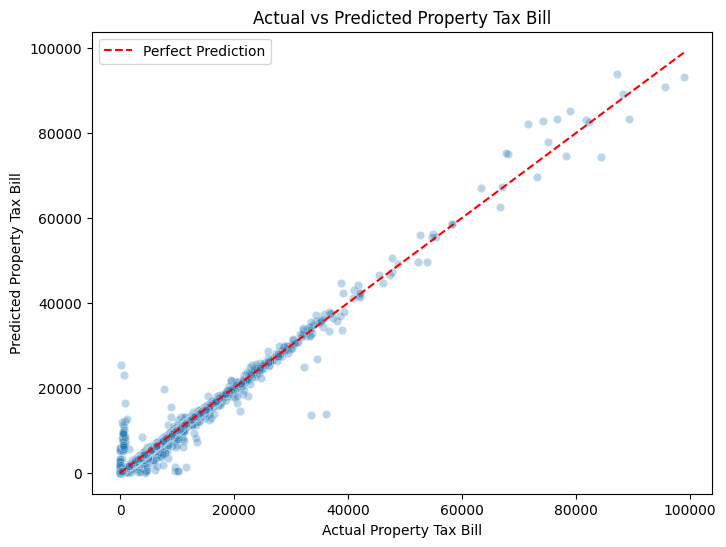

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=rf_pred, alpha=0.3)

plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", label="Perfect Prediction")

plt.xlabel("Actual Property Tax Bill")
plt.ylabel("Predicted Property Tax Bill")
plt.title("Actual vs Predicted Property Tax Bill")

plt.legend()
plt.show()

### The Random Forest model performed the best because predictions were closest to the perfect prediction line. This would suggest that the Random Forest model generalized the best and was able to predict property tax bills more accurately than the other models.

# **Feature Importance**

In [57]:
importance = rf_model.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

top_10 = feature_importance_df.head(10)

print(top_10)

                           Feature  Importance
0                       ASSESSMENT    0.970586
1                    TOTAL CREDITS    0.014726
38                  TAX CLASS_R074    0.003877
31                  TAX CLASS_R050    0.002188
2    RESIDENCE_PRINCIPAL RESIDENCE    0.001672
124                 CITY_ROCKVILLE    0.000707
77               CITY_GAITHERSBURG    0.000679
134               CITY_TAKOMA PARK    0.000569
25                  TAX CLASS_R042    0.000414
30                  TAX CLASS_R049    0.000352


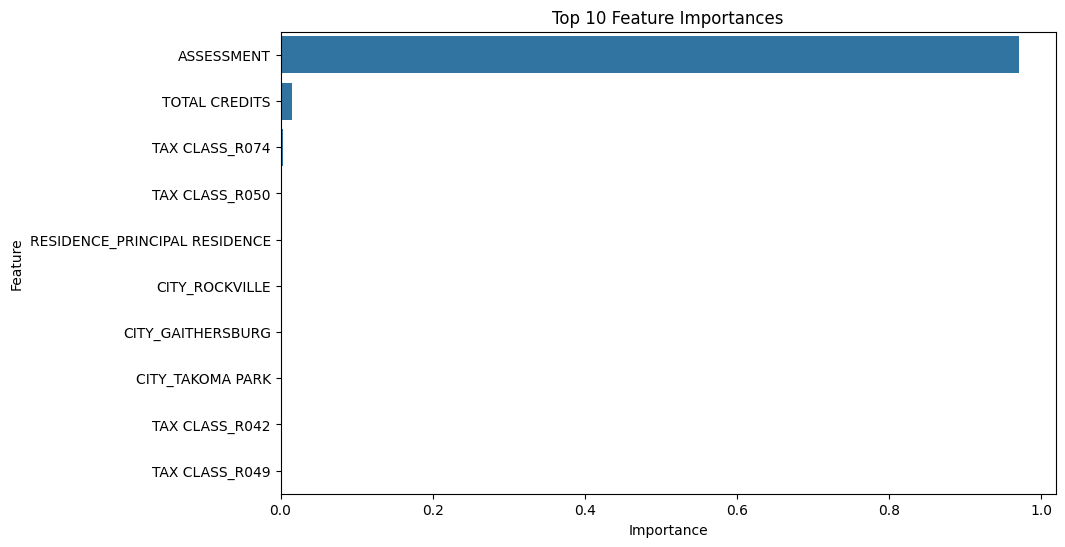

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_10
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

### The feature importance chart shows that the assessment value was the most important feature for predicting the total property tax bills. This checks out  because property taxes are closely connected to the assessed value of an actual property. Total credits was also important, but much less important than assessment as seen from the graph. Feature importance does not prove causation, but it helps show which variables were most useful for overall prediction.


# **Final Reflection**

## 1. Which model performed best?

### The model that performed best was the model with the highest r^2 and lowest RMSE.

## 2. Which model was easiest to explain?

### The single decision tree was easiest to explain as it follows one flowchart like structure. This made it easier to understand the root node, important splits, and prediction paths.

## 3. Which model would you choose in a real-world setting and why?

### In a real world setting, I think I would probably choose the Random Forest model as it usually gives better predictions while still being more stable comapored to a single decision tree. although the tradeoff is it would be harder to explain because it uses many trees instead of one.